# Семинар 1. Линейная регрессия

#### Шаг 1. Загрузка датасета и вывод на экран

In [ ]:
import pandas as pd

df_table = pd.read_csv('delivery_dataset.csv')
df_table.drop(['Дата заказа (ГГГГ-ММ-ДД)', 'Шифр заказа (ID)'], axis='columns', inplace=True)
print(df_table)

     Расстояние до клиента (в км)  Количество позиций в чеке (в шт.)  \
0                            11.3                                  1   
1                             7.3                                  3   
2                             2.2                                  1   
3                             0.9                                  2   
4                            12.3                                 14   
..                            ...                                ...   
495                           5.2                                  2   
496                          10.0                                  3   
497                           5.5                                  3   
498                           7.1                                  6   
499                           1.8                                  8   

     Балл пробок на дорогах (в баллах)  Погода (в градусах Цельсия)  \
0                                    9                         2

#### Шаг2. Разделение выборки на тренировочную, валидационную и тестовую с выбором нужных столбцов:
* в тренировочной: 300 первых заказов;
* в валидационной: 100 следующих; 
* в тестовой: 100 последних.

#### Вопрос 1. 

Для чего мы разбиваем данные на выборки? Для чего нам нужна тренировочная, для чего валидационная, для чего тестовая?

Ответ: для корректного обучения и проверки модели. Тренировочная выборка нужна для обучения модели - с помощью нее модель настраивает веса, видя признаки и правильные ответы. Она ищет закономерности и подстраивается. Далее валидационная. С помощью нее можно проследить , насколько правильно обучается модель. Это настраивание модели в процессе обучения для отслеживания ошибки и остановки в нужный момент. Так мы понимаем, что изменить в обучении. И последняя выборка - тестовая. Модель уже обучена и только проверяется на тестовых данных. Это дает понять, насколько обученная молель точна. 

In [17]:
import numpy as np

X_train, y_train = np.array(df_table.iloc[0:300, 0:-1]), np.array(df_table.iloc[0:300, -1:]).ravel()
print(X_train, y_train)
X_val, y_val = np.array(df_table.iloc[300:400, 0:-1]), np.array(df_table.iloc[300:400, -1:]).ravel()
X_test, y_test = np.array(df_table.iloc[400:, 0:-1]), np.array(df_table.iloc[400:, -1:]).ravel()


[[11.3  1.   9.  21.   6. ]
 [ 7.3  3.   7.  27.   7. ]
 [ 2.2  1.   3.  20.   5. ]
 ...
 [14.2  4.   6.  16.1 10. ]
 [ 5.5  1.   4.  26.1  8. ]
 [ 7.5  5.   3.  14.4  4. ]] [ 79.2  46.6  16.3  15.8  69.2  28.9  66.   11.   77.7  26.   77.8  13.1
 133.7  43.   32.5  71.4  27.2  39.4 129.1  16.4  61.6  83.7  95.8  79.8
  12.5  65.7  29.7  24.3  28.5  24.1  43.6  54.2  77.4 107.4  58.1  22.4
  14.8  82.8  33.2  16.6  18.8  32.   76.7  15.4  46.6  21.1  46.4  17.7
  16.8  24.4  11.5  33.3  21.7  18.6  68.1  13.9  18.9  21.   46.8  42.3
 127.1  29.3  32.8  45.   27.2  33.5  13.9  31.7  29.6  70.3  51.1  59.
  47.7  22.9  50.4  43.1  11.1  69.7  56.7  37.6  47.4  38.2  75.4  45.4
  30.3  46.7  80.9  26.5  17.   16.4  64.7  97.4  55.1  13.4  72.1  41.9
  24.3  96.9 105.4  38.8 106.   22.2  30.1  20.2  32.7  45.5  48.4 120.3
  25.5  34.1  32.9  42.8  18.9  61.   52.8  28.8  86.4  21.4  62.7  45.5
  38.6  16.   38.2  47.   11.4  16.   38.7  69.3  24.3  25.1  17.7  77.
   9.6 135.   64.8  50.5 

#### Шаг 3. Установка sklearn чтобы обучать модель линейной регрессии через Ridge

In [ ]:
# !pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


#### Шаг 4. Обучение модели линейной регрессии на тренировочной выборке с помощью Ridge и sparse_cg

In [18]:
from sklearn.linear_model import Ridge

model = Ridge(alpha=0.0, solver='sparse_cg')
model.fit(X_train, y_train)# Ваш код

,alpha,0.0
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'sparse_cg'
,positive,False
,random_state,None


#### Шаг 5. Вывод на экран графиков ошибок (SSE, MSE, RMSE) в зависимости от итераций для train и val выборок.

[np.float64(163810.37977750515), np.float64(9810.858410156776), np.float64(7347.51685720629), np.float64(5869.345386825997), np.float64(5666.3436013264945)] [np.float64(546.0345992583505), np.float64(32.70286136718925), np.float64(24.4917228573543), np.float64(19.564484622753323), np.float64(18.887812004421647)] [np.float64(23.367383235149596), np.float64(5.7186415665951), np.float64(4.948911280004351), np.float64(4.4231758525694325), np.float64(4.346011045133416)]
[np.float64(57593.9555224868), np.float64(3027.3565810590007), np.float64(2418.1784033311556), np.float64(2114.664586102867), np.float64(2133.1841231609365)] [np.float64(575.9395552248681), np.float64(30.273565810590007), np.float64(24.181784033311555), np.float64(21.14664586102867), np.float64(21.331841231609364)] [np.float64(23.9987407008132), np.float64(5.502141929338974), np.float64(4.917497741058104), np.float64(4.59854823406569), np.float64(4.618640625942807)]


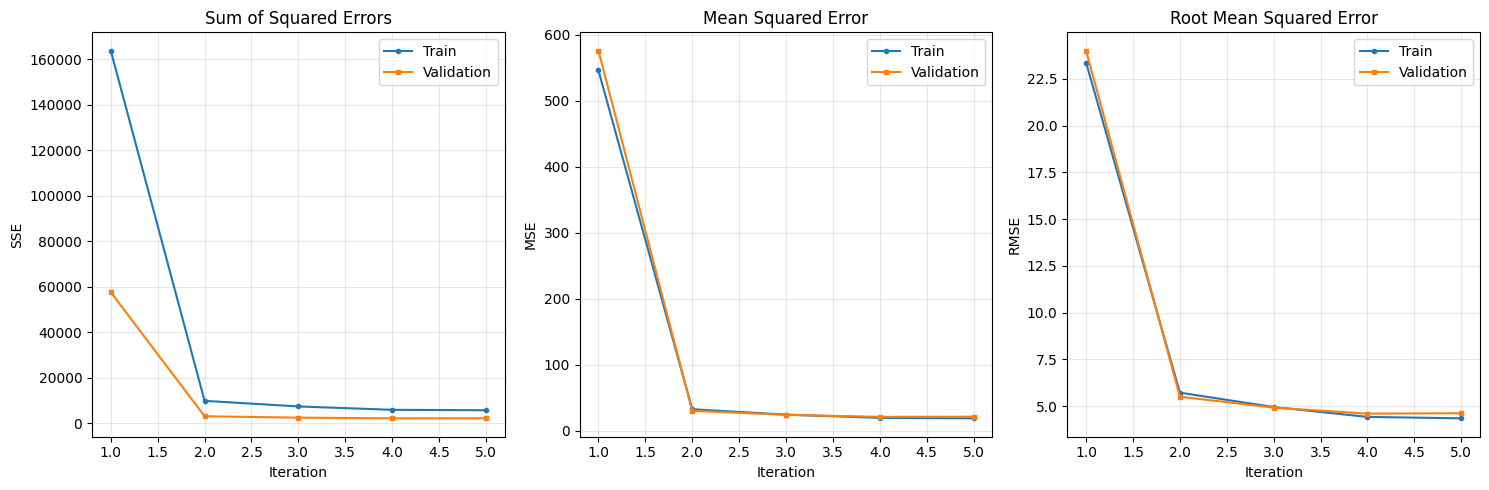

In [19]:
import matplotlib.pyplot as plt

epsilon = 0.0001
max_iter = 1000
SSE_train, MSE_train, RMSE_train = [], [], []
SSE_val, MSE_val, RMSE_val = [], [], []

A = np.dot(np.transpose(X_train), X_train)
b = np.dot(np.transpose(X_train), y_train)
w0 = np.array([0] * 5)
r0 = b - np.dot(A, w0)
p0 = r0

current_r, current_w, current_p = r0, w0, p0
for iter in range(1, max_iter):
    if np.linalg.norm(current_r) < epsilon:
        break
    step = np.divide(np.dot(np.transpose(current_r), current_r),  np.transpose(current_p) @ np.transpose(X_train) @ X_train @ current_p)
    new_w = current_w + np.dot(step, current_p)
    new_r = current_r - np.dot(np.dot(step, A), current_p)
    beta = np.divide(np.dot(np.transpose(new_r), new_r),  np.dot(np.transpose(current_r), current_r))
    new_p = new_r + np.dot(beta, current_p)

    current_r = new_r
    current_p = new_p
    current_w = new_w

    y_pred_train = np.dot(X_train, current_w)
    SSE_train.append(sum((y_train - y_pred_train) ** 2))
    MSE_train.append(SSE_train[-1] / len(X_train))
    RMSE_train.append(np.sqrt(MSE_train[-1]))

    y_pred_val = np.dot(X_val, current_w)
    SSE_val.append(sum((y_val - y_pred_val) ** 2))
    MSE_val.append(SSE_val[-1] / len(X_val))
    RMSE_val.append(np.sqrt(MSE_val[-1]))


print(SSE_train, MSE_train, RMSE_train)
print(SSE_val, MSE_val, RMSE_val)

# Номера итераций (от 1 до len(SSE_train)+1)
iterations_train = range(1, len(SSE_train) + 1)
iterations_val = range(1, len(SSE_val) + 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# График 1: SSE
axes[0].plot(iterations_train, SSE_train, label='Train', marker='o', markersize=3)
axes[0].plot(iterations_val, SSE_val, label='Validation', marker='s', markersize=3)
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('SSE')
axes[0].set_title('Sum of Squared Errors')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# График 2: MSE
axes[1].plot(iterations_train, MSE_train, label='Train', marker='o', markersize=3)
axes[1].plot(iterations_val, MSE_val, label='Validation', marker='s', markersize=3)
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('MSE')
axes[1].set_title('Mean Squared Error')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# График 3: RMSE
axes[2].plot(iterations_train, RMSE_train, label='Train', marker='o', markersize=3)
axes[2].plot(iterations_val, RMSE_val, label='Validation', marker='s', markersize=3)
axes[2].set_xlabel('Iteration')
axes[2].set_ylabel('RMSE')
axes[2].set_title('Root Mean Squared Error')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

# Автоматическая подгонка отступов
plt.tight_layout()

# Показываем график
plt.show()


#### Вопрос 2.

Какую информацию про нашу модель несут эти графики?

Ответ: по графикам мы видим, как и с какой скоростью изменяются разные ошибки. На первом графике траектория изменения ошибки SSE - суммарная ошибка модели по всем объектам после какой либо итерации. Ошибка падает для обеих выборок - это говорит о том, что модель обучилась корректно. На втором графике - ошибка MSE. Это то же, что и SSE / <количество объектов>, чтобы понять какая средняя ошибка на один объект. И третий график - ошибка RMSE. То же, что и корень из MSE. Корень извлекается для того, чтобы получить среднюю ошибку для одного объекта в его единице измерения. В нашем случае время доставки измеряется в минутах, т.е. средняя ошибка времени доставки заказа равна k минут. 

#### Вопрос 3. 

Какая траектория линий train и val ошибок будет на графиках недообученной модели и почему?

Ответ: В какой то момент траектория стабилизируется и станет просто горизонтальной - ошибка перестанет падать, но ее значение будет высоким. Такое может произойти, если тренировочные данные недостаточно информативные или их мало. 

Какая траектория линий train и val ошибок будет на графиках обученной модели и почему?

Ответ: ошибка будет падать, достигнет минимума и стабилизируется для обеих выборок. Это говорит о том, что модель правильно обучилась, нашла закономерности и настроила веса так, что при получении совершенно новых данных она ошибается так же, как и на тренировочных. Модель не тупо запоминает правильные ответы, а подстраивается под них. В итоге она достигнет минимального значения ошибки, тогда обучение можно считать завершенным. 

Какая траектория линий train и val ошибок будет на графиках переобученной модели и почему?

Ответ: Траектория линии train будет идти вниз, а val в какой то момент - наверх. Это значит, что модель достигла уменьшения ошибки во время обучения путем запоминания правильных ответов, а не настройки весов. Соответственно, получив незнакомые данные, она не смогла угадать ответ с нужно точностью и ошибка поползла наверх. Переобучение может возникунуть из-за избытка признаков или итераций. 

#### Шаг 6. Применение модели на тестовой выборке

In [20]:
import pandas as pd

y_pred_test = np.dot(X_test, current_w)

metrics_df = pd.DataFrame({
    'Предсказанное время': y_pred_test,
    'Настоящее время': y_test,
    'Разница': y_pred_test - y_test
})

display(metrics_df)


,Предсказанное время,Настоящее время,Разница
0,33.598238,33.9,-0.301762
1,32.981513,33.1,-0.118487
2,21.544765,16.3,5.244765
3,35.110537,34.7,0.410537
4,18.422382,13.3,5.122382
...,...,...,...
95,30.756355,28.9,1.856355
96,54.324561,48.0,6.324561
97,30.056345,27.0,3.056345
98,42.273021,40.4,1.873021


#### Шаг 7. RMSE на тестовой выборке

In [22]:
RMSE_test = np.sqrt(sum((y_test - y_pred_test) ** 2) / len(X_test))
print(RMSE_test)

4.949682480780443


#### Вопрос 4.

Что получившийся RMSE может сказать о нашей модели?

Ответ: мы получили значение ~4.95, значит средняя ошибка времени доставки заказа составляет ~4.95 минут.